# Fig 3 — zero-shot generalization across platforms

Reproduces **Fig3** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Fig 3a setup — scRNA-seq imports + config
**🟢 light (reads caches)** · source: `eval_scrnaseq_confusion_matrices.ipynb cell 1`

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

APP_CACHE = NB / "_app_cache"
BENCH     = BENCHMARK_DB
OUT_DIR   = COMP / "scrnaseq_confusion"; OUT_DIR.mkdir(parents=True, exist_ok=True)
PALETTE   = {"Tumor": "#F4B183", "Normal": "#9DC3E6"}

NORMAL_EPI_TYPES    = {"Epithelial", "Enterocyte", "Goblet", "Stem", "Paneth"}
NORMAL_EPI_PELKA24  = {"early colonocyte", "colonocyte", "colon goblet cell",
                       "BEST4+ colonocyte", "intestinal crypt stem cell of colon",
                       "secretory cell", "tuft cell of colon",
                       "enteroendocrine cell of colon"}

### Fig 3a loaders — GT merge + DATASETS/merged{}
**🟡 moderate** · source: `eval_scrnaseq_confusion_matrices.ipynb cell 3`

In [ ]:
def _to_yt(label_series, tumor_set, normal_set):
    """Map per-cell labels -> 'Tumor' / 'Normal' / NaN (drop)."""
    out = pd.Series(np.full(len(label_series), np.nan, dtype=object), index=label_series.index)
    out[label_series.isin(tumor_set)]  = "Tumor"
    out[label_series.isin(normal_set)] = "Normal"
    return out


def load_chen2021():
    preds = pd.read_csv(APP_CACHE / "chen2021_preds.csv.gz")
    parts = []
    for sub in ["discovery", "validation"]:
        f = BENCH / f"Data_Chen2021_Colorectal/{sub}/Cells.csv"
        if f.exists():
            parts.append(pd.read_csv(f, usecols=["cell_name", "cell_type"]))
    gt = pd.concat(parts, ignore_index=True).drop_duplicates("cell_name")
    gt["y_true"] = _to_yt(gt["cell_type"],
                            tumor_set={"Adenoma_specific_cell", "Serrated_specific_cells"},
                            normal_set={"Epithelial"})
    m = preds.merge(gt[["cell_name", "cell_type", "y_true"]],
                     left_on="cell", right_on="cell_name", how="inner")
    return m


def _load_pelka_chen_lee_gt(dir_path, n_groups=None):
    parts = []
    if n_groups is None:
        files = [dir_path / "Cells.csv"]
    else:
        files = [dir_path / f"Group{g}/Cells{g}.csv" for g in range(1, n_groups + 1)]
    for f in files:
        if f.exists():
            parts.append(pd.read_csv(f, usecols=["cell_name", "cell_type"]))
    return pd.concat(parts, ignore_index=True).drop_duplicates("cell_name")


def load_pelka2021():
    preds = pd.read_csv(APP_CACHE / "pelka2021_preds.csv.gz")
    gt = _load_pelka_chen_lee_gt(BENCH / "Data_Pelka2021_Colorectal", n_groups=4)
    gt["y_true"] = _to_yt(gt["cell_type"],
                            tumor_set={"Malignant"}, normal_set=NORMAL_EPI_TYPES)
    return preds.merge(gt[["cell_name", "cell_type", "y_true"]],
                        left_on="cell", right_on="cell_name", how="inner")


def load_lee2020():
    preds = pd.read_csv(APP_CACHE / "lee2020_preds.csv.gz")
    gt = _load_pelka_chen_lee_gt(BENCH / "Data_Lee2020_Colorectal")
    gt["y_true"] = _to_yt(gt["cell_type"],
                            tumor_set={"Malignant"}, normal_set=NORMAL_EPI_TYPES)
    return preds.merge(gt[["cell_name", "cell_type", "y_true"]],
                        left_on="cell", right_on="cell_name", how="inner")


def load_khaliq2022():
    preds = pd.read_csv(APP_CACHE / "khaliq2022_preds.csv.gz")
    meta = pd.read_csv(APP_CACHE / "geo_downloads" / "khaliq_meta.csv.gz",
                        index_col=0, usecols=["Unnamed: 0", "Condition"])
    meta = meta.reset_index().rename(columns={"index": "cell_name"})
    meta["y_true"] = meta["Condition"].astype(str).map(
        {"Tumor": "Tumor", "Normal": "Normal"})
    return preds.merge(meta[["cell_name", "Condition", "y_true"]],
                        left_on="cell", right_on="cell_name", how="inner")


def load_pelka2024_primary():
    preds = pd.read_csv(APP_CACHE / "crc_progplast_preds.csv.gz")
    preds = preds[preds["anatomy"] == "Primary"].copy()
    # cellxgene atlas obs has cell_type col; read it backed-mode and lookup by barcode
    atlas = ad.read_h5ad(APP_CACHE / "crc_progplast_atlas.h5ad", backed="r")
    ct = atlas.obs[["cell_type"]].copy()
    ct["cell_type"] = ct["cell_type"].astype(str)
    ct = ct.reset_index().rename(columns={"index": "cell_name"})
    ct["y_true"] = _to_yt(ct["cell_type"],
                            tumor_set={"malignant cell"}, normal_set=NORMAL_EPI_PELKA24)
    return preds.merge(ct, left_on="cell", right_on="cell_name", how="inner")


# Chen 2021 (precancer not tumor) and Khaliq 2022 (no per-cell tumor label) excluded —
# their annotation schemes do not yield a fair Tumor/Normal-epithelial comparison.
DATASETS = [
    ("Pelka et al. 2021",          load_pelka2021),
    ("Elewaut et al. 2025 (primary)", load_pelka2024_primary),
    ("Lee et al. 2020",            load_lee2020),
]

merged = {}
for label, fn in DATASETS:
    print(f"  loading {label} ...")
    m = fn().dropna(subset=["y_true", "spatnic_pred"])
    m = m[m["spatnic_pred"].isin(["Tumor", "Normal"])]
    n_tot   = len(m)
    n_tumor = int((m["y_true"] == "Tumor").sum())
    n_norm  = int((m["y_true"] == "Normal").sum())
    print(f"    n={n_tot:,}  (GT Tumor={n_tumor:,}, GT Normal={n_norm:,})")
    merged[label] = m

### Fig 3a — scRNA-seq confusion (Pelka/Moorman/Lee)
**🟢 light (reads caches)** · source: `eval_scrnaseq_confusion_matrices.ipynb cell 5`

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), constrained_layout=True)
labels_axis = ["Normal", "Tumor"]
summary_rows = []

for ax, (label, _) in zip(axes, DATASETS):
    m = merged[label]
    y_true = (m["y_true"]      == "Tumor").astype(int).values
    y_pred = (m["spatnic_pred"] == "Tumor").astype(int).values
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_n   = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    ax.imshow(cm_n, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_n[i, j]*100:.1f}%)",
                    ha="center", va="center", fontsize=12,
                    color="black" if cm_n[i, j] < 0.55 else "white")
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels_axis, fontsize=12)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels_axis, fontsize=12)
    ax.set_xlabel("SPATNIC", fontsize=13)
    ax.set_ylabel("Original annotation", fontsize=13)
    ax.set_title(f"{label}\n(n={len(m):,})", fontsize=13, pad=6)

    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    summary_rows.append({
        "dataset": label, "n": len(m),
        "n_tumor_gt": int(y_true.sum()), "n_normal_gt": int((1 - y_true).sum()),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "sensitivity": sens, "specificity": spec,
        "accuracy": (tp + tn) / max(len(m), 1),
    })

fig.suptitle("SPATNIC vs. original cell-type annotation — scRNA-seq CRC cohorts",
             fontsize=15, fontweight="bold", y=1.03)
fig.savefig(OUT_DIR / "scrnaseq_confusion_matrices.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT_DIR / "scrnaseq_confusion_matrices.pdf", bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / "scrnaseq_confusion_summary.csv", index=False)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
summary

### Fig 3b — per-modality champion spatial
**🔴 heavy (GPU / multi-GB / long)** · source: `fig_champion_spatial.ipynb cell 2`

In [ ]:
import json, numpy as np, pandas as pd
from pathlib import Path
import matplotlib as mpl; mpl.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import anndata as ad
from PIL import Image; Image.MAX_IMAGE_PIXELS=None
NBP=NB; APP=NBP/"comparison_results/applicability"
LC={"Tumor":"#F4B183","Normal":"#9DC3E6"}
panels=[]

# 1) Visium V1/V2 (Valdeolivas S5)
sid="SN048_A121573_Rep1"; sr=Path(str(Path.home()/'BICRC'))/"data/valdeolivas_spaceranger"/sid
img=plt.imread(sr/"spatial/tissue_hires_image.png")
sf=json.load(open(sr/"spatial/scalefactors_json.json")); sc=sf["tissue_hires_scalef"]
pos=pd.read_csv(sr/"spatial/tissue_positions_list.csv",header=None,names=["barcode","in_tissue","row","col","pyf","pxf"]).set_index("barcode")
pv=pd.read_csv(NBP/"comparison_results/visium_v1v2_groundtruth/per_spot_predictions.csv.gz")
pv=pv[(pv["sample"]==sid)&(pv["gt_label"].isin(["Tumor","Normal"]))]
m=pv.merge(pos[["pyf","pxf"]],left_on="barcode",right_index=True)
panels.append(dict(mod="Visium V1/V2",name="Valdeolivas 2024",img=img,he=True,x=(m["pxf"]*sc).to_numpy(),y=(m["pyf"]*sc).to_numpy(),
    gt=m["gt_label"].to_numpy(),pred=m["spatnic_pred"].to_numpy(),xlim=(0,img.shape[1]),ylim=(img.shape[0],0),ps=6,um_per=3.386))

# 2) Visium HD
img=plt.imread(str(BENCHMARK_DB/"VisiumHD_CRC/Visium_HD_Human_Colon_Cancer_spatial/spatial/tissue_hires_image.png"))
scH=0.07973422
hp=pd.read_csv(str(APP/"hd16_positions.csv")).set_index("barcode")
hd=pd.read_csv(NBP/"comparison_results/visium_hd/visium_hd_16um_predictions.csv.gz").rename(columns={"Unnamed: 0":"barcode"})
hd=hd[hd["gt_label"].isin(["Tumor","Normal"])]
m=hd.merge(hp[["pxl_row_in_fullres","pxl_col_in_fullres"]],left_on="barcode",right_index=True)
xs=(m["pxl_col_in_fullres"]*scH).to_numpy(); ys=(m["pxl_row_in_fullres"]*scH).to_numpy()
panels.append(dict(mod="Visium HD",name="10x Genomics",img=img,he=True,x=xs,y=ys,
    gt=m["gt_label"].to_numpy(),pred=m["spatnic_pred"].to_numpy(),
    xlim=(xs.min()-20,xs.max()+20),ylim=(ys.max()+20,ys.min()-20),ps=0.2,um_per=3.433))

# 3) CosMx exp2, champion patient T1_NANO_022 (6k panel; no H&E; H&E row = DAPI cell intensity)
cx=pd.read_csv(APP/"cosmx_exp2_predictions.csv.gz")
cx=cx[(cx["patient"]=="T1_NANO_022")&(cx["gt"].isin(["Tumor","Normal"]))]
dapi=cx["dapi"].to_numpy(); _cxx=cx["x"].to_numpy(); _cxy=cx["y"].to_numpy()
panels.append(dict(mod="CosMx",name="Buissant 2026 (T1sm1)",img=None,he=False,morph=dapi,x=_cxx,y=_cxy,
    gt=cx["gt"].to_numpy(),pred=cx["spatnic_pred"].to_numpy(),
    xlim=(_cxx.min(),_cxx.max()),ylim=(_cxy.max(),_cxy.min()),ps=0.6,um_per=1000.0))

# 4) Xenium V1 (H&E)
a=ad.read_h5ad(APP/"singlecell_annotate_cache/Xenium_V1.h5ad")
he=np.load(APP/"singlecell_annotate_cache/Xenium_V1_he.npy"); hw,hh=int(a.uns["he_w"]),int(a.uns["he_h"])
ann=pd.read_csv(APP/"singlecell_annotations/Xenium_V1.csv").set_index("barcode")["label"]
obs=pd.DataFrame(index=a.obs_names.astype(str)); obs["pred"]=a.obs["spatnic"].astype(str).values
obs["x"]=a.obsm["spatial"][:,0]; obs["y"]=a.obsm["spatial"][:,1]; obs["gt"]=obs.index.map(ann)
obs=obs[obs["gt"].isin(["Tumor","Normal"])]
panels.append(dict(mod="Xenium V1",name="10x Genomics (P5)",img=he,he=True,x=obs["x"].to_numpy(),y=obs["y"].to_numpy(),
    gt=obs["gt"].to_numpy(),pred=obs["pred"].to_numpy(),extent=[0,hw,hh,0],xlim=(0,hw),ylim=(hh,0),ps=0.4,um_per=1.0))

# 5) MERSCOPE P1 (no H&E/DAPI; grey cell positions like CosMx)
a=ad.read_h5ad(APP/"singlecell_annotate_cache/MERSCOPE_P1.h5ad")
ann=pd.read_csv(APP/"singlecell_annotations/MERSCOPE_P1.csv").set_index("barcode")["label"]
obs=pd.DataFrame(index=a.obs_names.astype(str)); obs["pred"]=a.obs["spatnic"].astype(str).values
obs["x"]=a.obsm["spatial"][:,0]; obs["y"]=a.obsm["spatial"][:,1]; obs["gt"]=obs.index.map(ann)
obs=obs[obs["gt"].isin(["Tumor","Normal"])]
_mx=obs["x"].to_numpy(); _my=obs["y"].to_numpy()
panels.append(dict(mod="MERSCOPE",name="Vizgen (P1)",img=None,he=False,x=_mx,y=_my,
    gt=obs["gt"].to_numpy(),pred=obs["pred"].to_numpy(),
    xlim=(_mx.min(),_mx.max()),ylim=(_my.max(),_my.min()),ps=0.3,um_per=1.0))

def nice_len(w_um):
    t=w_um*0.22
    for b in [50,100,200,500,1000,2000,5000,10000,20000]:
        if b>=t: return b
    return 20000
# aspect -> width_ratios
def aspect(p):
    (x0,x1)=p["xlim"]; (y0,y1)=p["ylim"]; return abs(x1-x0)/max(1e-9,abs(y1-y0))
asp=[min(1.95,max(0.5,aspect(p))) for p in panels]
n=len(panels); rows=["H&E / morphology","Ground truth","SPATNIC prediction"]; RH=2.9
fig,axes=plt.subplots(3,n,figsize=(sum(asp)*RH+0.6,3*RH),dpi=120,squeeze=False,
                      gridspec_kw=dict(width_ratios=asp,wspace=0.06,hspace=0.06))
for c,p in enumerate(panels):
    x,y,gt,pred=p["x"],p["y"],p["gt"],p["pred"]; ps=p.get("ps",4); tf=(gt=="Tumor").mean()
    for r in range(3):
        ax=axes[r,c]
        if p["img"] is not None:
            ax.imshow(p["img"],extent=p.get("extent"),aspect="auto",cmap=("gray" if p.get("dapi") else None))
        if r==0 and p["img"] is None:                                   # CosMx: DAPI-intensity cells
            mvals=p.get("morph");
            if mvals is not None:
                lo,hi=np.nanpercentile(mvals,[5,95])
                ax.scatter(x,y,s=ps,c=np.clip((mvals-lo)/max(1,hi-lo),0,1),cmap="gray_r",linewidths=0)
            else: ax.scatter(x,y,s=ps,c="0.78",linewidths=0)
        if r==1:
            for k in ["Tumor","Normal"]:
                mm=gt==k
                if mm.any(): ax.scatter(x[mm],y[mm],s=ps,c=LC[k],linewidths=0)
        if r==2:                                   # errors behind, correct on top
            err=pred!=gt                           # -> cancer front in cancer regions, normal front in normal regions
            for layer in (err,~err):
                for k in ["Tumor","Normal"]:
                    mm=layer&(pred==k)
                    if mm.any(): ax.scatter(x[mm],y[mm],s=ps,c=LC[k],linewidths=0)
        if r==2 and p.get("um_per"):
            um=p["um_per"]; wdat=abs(p["xlim"][1]-p["xlim"][0]); L=nice_len(wdat*um); frac=(L/um)/wdat
            x0=0.06
            ax.plot([x0,x0+frac],[0.06,0.06],transform=ax.transAxes,color="white",lw=4.5,solid_capstyle="butt",zorder=10)
            ax.plot([x0,x0+frac],[0.06,0.06],transform=ax.transAxes,color="black",lw=2.5,solid_capstyle="butt",zorder=11)
            lab=(f"{L/1000:g} mm" if L>=1000 else f"{L:g} µm")
            ax.text(x0+frac/2,0.105,lab,transform=ax.transAxes,ha="center",va="bottom",fontsize=8,color="black",
                    bbox=dict(boxstyle="round,pad=0.15",fc="white",ec="none",alpha=0.8),zorder=12)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(*p["xlim"]); ax.set_ylim(*p["ylim"]); ax.set_aspect("auto")
        for sp in ax.spines.values(): sp.set_linewidth(0.6); sp.set_color("0.5")
    axes[0,c].set_title(p["mod"],fontsize=11,fontweight="bold",pad=13)
    axes[0,c].text(0.5,1.012,p["name"],transform=axes[0,c].transAxes,ha="center",va="bottom",fontsize=7.5,color="0.35")
for r in range(3): axes[r,0].set_ylabel(rows[r],fontsize=12.5,fontweight="bold")
h=[Patch(color=LC[k],label=("Cancer" if k=="Tumor" else "Normal")) for k in ["Tumor","Normal"]]
fig.legend(handles=h,loc="lower center",bbox_to_anchor=(0.5,-0.02),fontsize=12,frameon=False,ncol=2)
fig.suptitle("SPATNIC (zero-shot) across platforms — one champion sample per modality",fontsize=15,fontweight="bold",y=1.005)
OUTP=APP
fig.savefig(OUTP/"champion_spatial_per_modality.png",dpi=150,bbox_inches="tight")
fig.savefig(OUTP/"champion_spatial_per_modality.pdf",bbox_inches="tight")
plt.show()
print("aspects:",[round(a,2) for a in asp]); print("saved")

### Fig 3c setup — c2l minitest config
**🟢 light (reads caches)** · source: `c2l_minitest_eval.ipynb cell 1`

In [ ]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             average_precision_score, f1_score)

# ============================================================
# CHANGE THESE
REFERENCE = 'pelka'             # 'lee' or 'pelka'
SAMPLE_ID = 'SN123_A595688_Rep1'
# ============================================================

assert REFERENCE in ('lee', 'pelka'), f'REFERENCE must be lee or pelka; got {REFERENCE}'

VISIUM_SAMPLES = {
    'SN048_A121573_Rep2':  {'source': 'dsid',        'path': 'DSID001466'},
    'SN123_A595688_Rep1':  {'source': 'dsid',        'path': 'DSID001470'},
    'SN124_A798015_Rep2':  {'source': 'dsid',        'path': 'DSID001475'},
    'SN124_A938797_Rep2':  {'source': 'dsid',        'path': 'DSID001476'},
    'SN84_A120838_Rep2':   {'source': 'dsid',        'path': 'DSID001478'},
    'SN048_A121573_Rep1':  {'source': 'spaceranger', 'path': 'SN048_A121573_Rep1'},
    'SN048_A416371_Rep1':  {'source': 'spaceranger', 'path': 'SN048_A416371_Rep1'},
    'SN048_A416371_Rep2':  {'source': 'spaceranger', 'path': 'SN048_A416371_Rep2'},
    'SN84_A120838_Rep1':   {'source': 'spaceranger', 'path': 'SN84_A120838_Rep1'},
    'SN123_A551763_Rep1':  {'source': 'spaceranger', 'path': 'SN123_A551763_Rep1'},
    'SN123_A798015_Rep1':  {'source': 'spaceranger', 'path': 'SN123_A798015_Rep1'},
    'SN123_A938797_Rep1_X':{'source': 'spaceranger', 'path': 'SN123_A938797_Rep1_X'},
    'SN124_A595688_Rep2':  {'source': 'spaceranger', 'path': 'SN124_A595688_Rep2'},
}
VISIUM_DATA_ROOT = Path(str(Path.home()/'BICRC')) / 'data'
VISIUM_SR_ROOT   = VISIUM_DATA_ROOT / 'valdeolivas_spaceranger'

info = VISIUM_SAMPLES[SAMPLE_ID]
if info['source'] == 'dsid':
    VISIUM_DIR = VISIUM_DATA_ROOT / info['path']
else:
    VISIUM_DIR = VISIUM_SR_ROOT / info['path']

MINI_DIR  = DATA_ROOT / 'c2l_minitest'
# Primary mode used by single-mode sections §2-§7 (default original)
PRIMARY_MODE = 'original'
INF_H5    = MINI_DIR / f'{SAMPLE_ID}_{REFERENCE}_{PRIMARY_MODE}.h5ad'
INF_PQ    = MINI_DIR / f'{REFERENCE}_{PRIMARY_MODE}_inf_aver.parquet'
PATHO_CSV = (Path('comparison_results/visium_v1v2_groundtruth/pathologist_annotations')
             / f'Pathologist_Annotations_{SAMPLE_ID}.csv')
OUT_DIR   = (Path('comparison_results/c2l_minitest') / REFERENCE / SAMPLE_ID).resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

PAL = {'Tumor': '#F4B183', 'Normal': '#9DC3E6', 'Other': '#bbbbbb'}
PATHO_TO_BINARY = {
    # tumor — adenocarcinoma 領域
    'tumor':                              'Tumor',
    'tumor&stroma':                       'Tumor',
    'tumor&stroma_IC low':                'Tumor',
    'tumor&stroma_IC med to high':        'Tumor',
    'tumor&stroma IC med to high':        'Tumor',
    # normal colonic epithelium — SPATNIC の Normal クラスと同種
    'non neo epithelium':                 'Normal',
    'epithelium&submucosa':               'Normal',
    'epitehlium&submucosa':               'Normal',
    'epithelium&lam propria':             'Normal',
}
print('REFERENCE =', REFERENCE)
print('SAMPLE_ID =', SAMPLE_ID)
print('VISIUM_DIR=', VISIUM_DIR)
print('INF_H5    =', INF_H5, '   exists:', INF_H5.exists())
print('OUT_DIR   =', OUT_DIR)

### Fig 3c — load c2l posterior + pathology + H&E
**🟡 moderate** · source: `c2l_minitest_eval.ipynb cell 3`

In [ ]:
a = ad.read_h5ad(INF_H5)
print(f'c2l inference: {a.n_obs:,} spots × {a.n_vars:,} genes')

factor_names = list(a.uns.get('mod', {}).get('factor_names', ['Normal', 'Tumor']))
print('factor_names from uns:', factor_names)

# Cell-type abundance (posterior q05). Find the q05 obsm key first.
key = 'q05_cell_abundance_w_sf'
if key not in a.obsm:
    for k in a.obsm.keys():
        if 'q05' in k and 'abundance' in k:
            key = k; break
print('using obsm key:', key)

abun = a.obsm[key]
if isinstance(abun, np.ndarray):
    abun = pd.DataFrame(abun, index=a.obs_names, columns=factor_names)
else:
    abun = abun.copy()

print('raw abundance columns:', list(abun.columns))

# Rename columns by matching each known factor name as a SUFFIX of the column.
# cell2location 0.1.5 stores cols as 'q05cell_abundance_w_sf_<factor>' (no underscore
# between q05 and cell), so prefix-stripping fails. Suffix match is robust.
new_cols = []
for c in abun.columns:
    matched = None
    for f in factor_names:
        if str(c).endswith(f):
            matched = f; break
    new_cols.append(matched if matched else c)
abun.columns = new_cols
print('renamed abundance columns:', list(abun.columns))

missing = [f for f in factor_names if f not in abun.columns]
if missing:
    raise KeyError(f'expected factor_names {factor_names} but missing {missing} '
                   f'after rename. Got columns: {list(abun.columns)}')

print(abun.describe().round(3))

tot = abun.sum(axis=1).clip(lower=1e-9)
tumor_frac = (abun['Tumor'] / tot).astype(float)
argmax_label = abun.idxmax(axis=1)

# pathology
pa = pd.read_csv(PATHO_CSV); pa.columns = [c.strip() for c in pa.columns]
pa_col = [c for c in pa.columns if c != 'Barcode'][0]
patho_raw = pa.set_index('Barcode')[pa_col].astype(str)
patho_bin = patho_raw.map(PATHO_TO_BINARY).fillna('Other')
print('pathology raw counts :', patho_raw.value_counts().to_dict())
print('pathology binarised  :', patho_bin.value_counts().to_dict())

# H&E
sp_dir = VISIUM_DIR / 'spatial'
he = np.asarray(Image.open(sp_dir / 'tissue_hires_image.png').convert('RGB'))
sf = json.loads((sp_dir / 'scalefactors_json.json').read_text())['tissue_hires_scalef']
xy = np.asarray(a.obsm['spatial'], float) * sf

# Combine into a tidy DataFrame
df = pd.DataFrame({
    'x':       xy[:, 0],
    'y':       xy[:, 1],
    'Tumor':   abun['Tumor'].values,
    'Normal':  abun['Normal'].values,
    'tumor_frac': tumor_frac.values,
    'argmax':  argmax_label.values,
    'patho_raw': patho_raw.reindex(a.obs_names).values,
    'patho_bin': patho_bin.reindex(a.obs_names).values,
}, index=a.obs_names)
df['patho_bin'] = df['patho_bin'].fillna('Other')
print(f'\nspots: {len(df)}   patho overlap: '
      f'{int(df["patho_bin"].isin(["Tumor","Normal"]).sum())}/'
      f'{len(df)} have Tumor/Normal pathology label')
df.head()

### Fig 3c — spatial overview panels
**🟡 moderate** · source: `c2l_minitest_eval.ipynb cell 5`

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

def _he(ax):
    ax.imshow(he, interpolation='bilinear')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ('top','right','left','bottom'):
        ax.spines[sp].set_visible(False)

# (0,0) H&E only
ax = axes[0, 0]; _he(ax); ax.set_title('H&E', fontsize=13, fontweight='bold')

# (0,1) Pathology
ax = axes[0, 1]; _he(ax)
for cls in ('Other', 'Normal', 'Tumor'):
    m = (df['patho_bin'] == cls)
    if m.any():
        ax.scatter(df.loc[m, 'x'], df.loc[m, 'y'], c=PAL[cls], s=14,
                   alpha=0.85, linewidths=0,
                   label=f'{cls} (n={int(m.sum())})')
ax.legend(loc='upper right', fontsize=10, markerscale=2, framealpha=0.9)
ax.set_title('Pathology', fontsize=13, fontweight='bold')

# (0,2) c2l argmax
ax = axes[0, 2]; _he(ax)
for cls in ('Normal', 'Tumor'):
    m = (df['argmax'] == cls)
    if m.any():
        ax.scatter(df.loc[m, 'x'], df.loc[m, 'y'], c=PAL[cls], s=14,
                   alpha=0.85, linewidths=0,
                   label=f'{cls} (n={int(m.sum())})')
ax.legend(loc='upper right', fontsize=10, markerscale=2, framealpha=0.9)
ax.set_title('c2l argmax (Tumor / Normal)', fontsize=13, fontweight='bold')

# (1,0) Tumor abundance
ax = axes[1, 0]; _he(ax)
sc1 = ax.scatter(df['x'], df['y'], c=df['Tumor'], cmap='inferno', s=16,
                  alpha=0.9, linewidths=0)
fig.colorbar(sc1, ax=ax, fraction=0.04, shrink=0.7, label='Tumor abundance (q05)')
ax.set_title(f'c2l Tumor abundance  mean={df["Tumor"].mean():.2f}',
              fontsize=13, fontweight='bold')

# (1,1) Normal abundance
ax = axes[1, 1]; _he(ax)
sc2 = ax.scatter(df['x'], df['y'], c=df['Normal'], cmap='viridis', s=16,
                  alpha=0.9, linewidths=0)
fig.colorbar(sc2, ax=ax, fraction=0.04, shrink=0.7, label='Normal abundance (q05)')
ax.set_title(f'c2l Normal abundance  mean={df["Normal"].mean():.2f}',
              fontsize=13, fontweight='bold')

# (1,2) Tumor fraction
ax = axes[1, 2]; _he(ax)
sc3 = ax.scatter(df['x'], df['y'], c=df['tumor_frac'], cmap='RdBu_r',
                  vmin=0, vmax=1, s=16, alpha=0.9, linewidths=0)
fig.colorbar(sc3, ax=ax, fraction=0.04, shrink=0.7,
             label='Tumor / (Tumor + Normal)')
ax.set_title(f'c2l Tumor fraction  mean={df["tumor_frac"].mean():.3f}',
              fontsize=13, fontweight='bold')

fig.suptitle('cell2location minitest — Lee 2020 reference, SN123_A551763_Rep1',
             fontsize=14, fontweight='bold')
out = OUT_DIR / 'spatial_overview.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'saved: {out}')
plt.show()

### Fig 3c — tumor fraction distribution
**🟢 light (reads caches)** · source: `c2l_minitest_eval.ipynb cell 7`

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# histogram
ax = axes[0]
for cls in ('Normal', 'Other', 'Tumor'):
    m = (df['patho_bin'] == cls)
    if m.any():
        ax.hist(df.loc[m, 'tumor_frac'], bins=30, alpha=0.55,
                 label=f'{cls} (n={int(m.sum())})', color=PAL[cls])
ax.set_xlabel('c2l Tumor fraction', fontsize=12)
ax.set_ylabel('# spots', fontsize=12)
ax.set_title('Tumor fraction by pathology class', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper center')

# boxplot — only show classes with cells
ax = axes[1]
cls_order = [c for c in ('Normal', 'Other', 'Tumor') if (df['patho_bin']==c).any()]
data = [df.loc[df['patho_bin']==c, 'tumor_frac'].values for c in cls_order]
bp = ax.boxplot(data, positions=range(len(cls_order)), widths=0.55,
                 patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], cls_order):
    patch.set_facecolor(PAL[c]); patch.set_edgecolor('#333')
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(1.4)
ax.set_xticks(range(len(cls_order)))
ax.set_xticklabels([f'{c}\n(n={int((df["patho_bin"]==c).sum())})' for c in cls_order],
                    fontsize=12)
ax.set_ylabel('c2l Tumor fraction', fontsize=12)
ax.set_ylim(-0.02, 1.02)
ax.set_title('Tumor fraction medians', fontsize=13, fontweight='bold')
for i, vals in enumerate(data):
    if len(vals):
        ax.text(i, 1.0, f'med={np.median(vals):.2f}',
                ha='center', va='bottom', fontsize=10, color='#333')
fig.suptitle('Distribution of c2l Tumor fraction by pathology label',
             fontsize=13, fontweight='bold')
out = OUT_DIR / 'tumor_frac_distribution.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'saved: {out}')
plt.show()

### Fig 3d setup — imports + vocab
**🟢 light (reads caches)** · source: `fig_crc_applicability_performance.ipynb cell 1`

In [ ]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.simplefilter("ignore")

APP_CACHE = Path("_app_cache")
CR        = Path("comparison_results")
OUT       = CR / "applicability"; OUT.mkdir(parents=True, exist_ok=True)
PALETTE   = {"Tumor": "#F4B183", "Normal": "#9DC3E6"}

try:
    from sklearn.metrics import roc_auc_score
    HAVE_SK = True
except Exception:
    HAVE_SK = False
    print("sklearn missing -> AUROC will be skipped")

# Normal-epithelium cell-type vocabularies for the cell-annotation GT datasets
NORMAL_EPI       = {"Epithelial", "Enterocyte", "Goblet", "Stem", "Paneth"}          # Pelka/Lee/Chen
NORMAL_EPI_ATLAS = {"early colonocyte", "colonocyte", "colon goblet cell",
                    "BEST4+ colonocyte", "intestinal crypt stem cell of colon",
                    "secretory cell", "tuft cell of colon", "enteroendocrine cell of colon"}

### Fig 3d — perf() + add() helpers
**🟢 light (reads caches)** · source: `fig_crc_applicability_performance.ipynb cell 2`

In [ ]:
def perf(gt, pred, score=None):
    """gt/pred are 'Tumor'/'Normal' label series. Returns a metrics dict.
    balacc/auroc require both classes; sens needs tumor, spec needs normal."""
    gt   = pd.Series(list(gt)).reset_index(drop=True)
    pred = pd.Series(list(pred)).reset_index(drop=True)
    y = (gt == "Tumor").astype(int); p = (pred == "Tumor").astype(int)
    tp = int(((y==1)&(p==1)).sum()); tn = int(((y==0)&(p==0)).sum())
    fp = int(((y==0)&(p==1)).sum()); fn = int(((y==1)&(p==0)).sum())
    has_t, has_n = (y==1).any(), (y==0).any()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    spec = tn/(tn+fp) if (tn+fp) else np.nan
    acc  = (tp+tn)/len(y) if len(y) else np.nan
    bal  = np.nanmean([sens, spec]) if (has_t and has_n) else np.nan
    f1   = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn) else np.nan
    au   = np.nan
    if score is not None and has_t and has_n and HAVE_SK:
        try: au = roc_auc_score(y, pd.Series(list(score)).reset_index(drop=True))
        except Exception: pass
    r = lambda v: round(float(v), 3) if v == v else None
    return dict(n=len(y), n_tumor=int(y.sum()), n_normal=int((1-y).sum()),
                acc=r(acc), balacc=r(bal), sens=r(sens), spec=r(spec), f1=r(f1), auroc=r(au))

PERF = {}   # keyed by (dataset_label, anatomy)
def add(label, anatomy, m, note=""):
    m = dict(m); m["note"] = note
    PERF[(label, anatomy)] = m
    print(f"  {label:34s} [{anatomy:9s}]  "
          + "  ".join(f"{k}={m[k]}" for k in ("balacc","sens","spec","auroc") if m.get(k) is not None)
          + (f"   ! {note}" if note else ""))

### Fig 3d — spot-level GT perf
**🟡 moderate** · source: `fig_crc_applicability_performance.ipynb cell 3`

In [ ]:
# ---------- pathologist / spot-level GT (both classes) ----------
d = pd.read_csv(CR/"visium_v1v2_groundtruth/per_spot_predictions.csv.gz")
m = d[d["gt_label"].isin(["Tumor","Normal"])]
add("Valdeolivas et al. 2024", "Primary", perf(m["gt_label"], m["spatnic_pred"], m["spatnic_score"]))

d = pd.read_csv(CR/"visium_hd/visium_hd_16um_predictions.csv.gz")
m = d[d["gt_label"].isin(["Tumor","Normal"])]
add("10x Genomics Visium HD", "Primary", perf(m["gt_label"], m["spatnic_pred"], m["spatnic_score"]))

# Oliveira 2025 Visium HD — GT embedded as UnsupervisedL1 (Tumor / Intestinal Epithelial)
d = pd.read_csv(APP_CACHE/"oliveira2025_visiumHD_16um_preds.csv.gz")
g = d.assign(gt=d["UnsupervisedL1"].map(lambda v: "Tumor" if v=="Tumor"
             else ("Normal" if v=="Intestinal Epithelial" else None))).dropna(subset=["gt"])
add("Oliveira et al. 2025 Visium HD", "Primary", perf(g["gt"], g["spatnic_pred"], g["spatnic_score"]))

# ---------- Xenium V1 P5 — Tumor vs NON-EPITHELIAL (immune/vascular/neural) ----------
# 10x Xenium V1 P5: the public novae GT only annotates Cancer vs non-epithelial cells
# (Vascular/Immune/Neural) — there is NO normal epithelium, so a cancer-vs-normal-epithelium
# performance is not computable here. => APPLICABILITY-ONLY: not added to PERF (metric shows "—").
# (For reference, on a proper Xenium cancer-vs-normal-epi GT, SPATNIC reaches BA 0.96 / AUROC 0.99.)
# d = pd.read_csv(CR/"xenium/xenium_tumor_normal_predictions.csv.gz")  # kept for the record

### Fig 3d — scRNA atlas cell-type perf
**🟡 moderate** · source: `fig_crc_applicability_performance.ipynb cell 4`

In [ ]:
# ---------- scRNA-seq atlases with cell-type GT (join cached preds -> Cells.csv) ----------
def join_celltype(pred_csv, cells_paths):
    pp = pd.read_csv(APP_CACHE/pred_csv)
    cs = [pd.read_csv(p, low_memory=False) for p in cells_paths if Path(p).exists()]
    c  = pd.concat(cs).rename(columns={"cell_name":"cell"})
    mm = pp.merge(c[["cell","cell_type"]], on="cell", how="left")
    matched = mm["cell_type"].notna().mean()
    return mm, matched

BDB = BENCHMARK_DB
mm, mr = join_celltype("pelka2021_preds.csv.gz",
        [BDB/f"Data_Pelka2021_Colorectal/Group{g}/Cells{g}.csv" for g in range(1,5)])
mm = mm[mm["cell_type"].isin({"Malignant"}|NORMAL_EPI)].copy()
mm["gt"] = np.where(mm["cell_type"]=="Malignant","Tumor","Normal")
add("Pelka et al. 2021", "Primary", perf(mm["gt"], mm["spatnic_pred"], mm["spatnic_score"]),
    note=f"join match {mr:.2f}")

mm, mr = join_celltype("lee2020_preds.csv.gz", [BDB/"Data_Lee2020_Colorectal/Cells.csv"])
mm = mm[mm["cell_type"].isin({"Malignant"}|NORMAL_EPI)].copy()
mm["gt"] = np.where(mm["cell_type"]=="Malignant","Tumor","Normal")
add("Lee et al. 2020", "Primary", perf(mm["gt"], mm["spatnic_pred"], mm["spatnic_score"]),
    note=f"only {int((mm['gt']=='Normal').sum())} normal-epi cells; join {mr:.2f}")

# Chen 2021 — HTAN polyp atlas: all Epithelial = normal/precancer (no advanced CRC) -> specificity
mm, mr = join_celltype("chen2021_preds.csv.gz",
        [BDB/"Data_Chen2021_Colorectal/discovery/Cells.csv", BDB/"Data_Chen2021_Colorectal/validation/Cells.csv"])
mm = mm[mm["cell_type"]=="Epithelial"].copy(); mm["gt"] = "Normal"
add("Chen et al. 2021", "Primary", perf(mm["gt"], mm["spatnic_pred"], mm["spatnic_score"]),
    note="precancer/normal epithelium only -> specificity")

### Fig 3d — metastasis atlas + single-class perf
**🟡 moderate** · source: `fig_crc_applicability_performance.ipynb cell 5`

In [ ]:
# ---------- Progressive-plasticity CRC metastasis atlas (cellxgene) ----------
import anndata as ad
a  = ad.read_h5ad(APP_CACHE/"crc_progplast_atlas.h5ad", backed="r")
ct = a.obs["cell_type"].astype(str); ct.index = a.obs_names.astype(str)
pp = pd.read_csv(APP_CACHE/"crc_progplast_preds.csv.gz"); pp["ct"] = pp["cell"].map(ct)
pp = pp[pp["ct"].isin({"malignant cell"}|NORMAL_EPI_ATLAS)].copy()
pp["gt"] = np.where(pp["ct"]=="malignant cell","Tumor","Normal")
add("Moorman et al. 2025", "Primary",
    perf(pp[pp.anatomy=="Primary"]["gt"], pp[pp.anatomy=="Primary"]["spatnic_pred"], pp[pp.anatomy=="Primary"]["spatnic_score"]))
for anat in ("Liver met","Lung met"):
    sub = pp[pp.anatomy==anat]
    if len(sub):
        add("Moorman et al. 2025", anat, perf(sub["gt"], sub["spatnic_pred"], sub["spatnic_score"]),
            note="met compartment = cancer-only -> sensitivity")

# ---------- single-class biological gold standards ----------
o = pd.read_csv(CR/"scrnaseq/cancerCellLine/SPATNIC.csv", index_col=0).loc["__OVERALL__"]
add("Cancer cell lines", "Primary", dict(n=int(o["n_cells"]), sens=round(float(o["sensitivity"]),3),
    spec=None, balacc=None, auroc=None, acc=round(float(o["accuracy"]),3), n_tumor=int(o["n_cells"]), n_normal=0),
    note="100% cancer (epithelial CRC cell lines)")
# Epithelial-RESTRICTED: drop legacy non-epi SS2 plates (Immune/Endothelial/Stromal);
# keep 10x samples (curated cell_type all epithelial) + SS2 Epithelial plates.
_tab = pd.read_csv(CR/"scrnaseq/normalEpithelial/SPATNIC.csv", index_col=0)
_tab = _tab[_tab.index != "__OVERALL__"]
_nonepi = _tab.index.to_series().str.rsplit("_", n=1).str[-1].isin(["Immune","Endothelial","Stromal"])
_epi = _tab[~_nonepi]
_tn = (_epi["specificity"]*_epi["n_cells"]).round().sum(); _n = int(_epi["n_cells"].sum())
add("Tabula Sapiens colon", "Primary", dict(n=_n, spec=round(_tn/_n,3),
    sens=None, balacc=None, auroc=None, acc=round(_tn/_n,3), n_tumor=0, n_normal=_n),
    note=f"healthy colon EPITHELIUM only ({_n} cells; dropped {int(_tab['n_cells'][_nonepi].sum())} non-epi)")

# Oliveira 2025 DTCs — disseminated tumor cells, all tumor -> sensitivity
d = pd.read_csv(APP_CACHE/"oliveira2025_dtcs_preds.csv.gz")
sens = round((d["spatnic_pred"]=="Tumor").mean(), 3)
add("Oliveira et al. 2025 DTCs", "Liver met",
    dict(n=len(d), sens=sens, spec=None, balacc=None, auroc=None, acc=sens, n_tumor=len(d), n_normal=0),
    note="disseminated tumor cells = epithelial-derived cancer")

perf_df = pd.DataFrame([{**{"dataset":k[0],"anatomy":k[1]}, **v} for k,v in PERF.items()])
perf_df.to_csv(OUT/"applicability_performance.csv", index=False)
perf_df

### Fig 3d — met-specific models on met tissue
**🔴 heavy (GPU / multi-GB / long)** · source: `fig_crc_applicability_performance.ipynb cell 6`

In [ ]:
# ============================================================================
# Met-specific models on met tissue (user decision): liver met -> liver_ft model,
# lung met -> lung_ft model. Primary tissue keeps the primary tumor_normal model.
# These OVERWRITE the primary-model met entries computed above.
# ============================================================================
from pathlib import Path as _P
import scanpy as _sc, anndata as _ad, gc as _gc
import spatnic
LIVER_MODEL = str(_P.home()/".spatnic/weights/tumor_normal_liver_ft.pt")
LUNG_MODEL  = str(_P.home()/".spatnic/weights/tumor_normal_lung_ft.pt")
_NEA = {"early colonocyte","colonocyte","colon goblet cell","BEST4+ colonocyte",
        "intestinal crypt stem cell of colon","secretory cell","tuft cell of colon","enteroendocrine cell of colon"}
_TMAP = {'liver':'Liver met','lung':'Lung met','peritoneum':'Liver met','chest wall':'Liver met'}

def _se(adata, model):
    a = adata.copy(); a.var_names_make_unique()
    _sc.pp.normalize_total(a); _sc.pp.log1p(a)
    spatnic.predict(a, model=model)
    return round((a.obs["spatnic_pred"].astype(str)=="Tumor").mean(), 3), a.n_obs

# --- Moorman atlas: liver/lung met malignant epithelial cells ---
_a = _ad.read_h5ad(APP_CACHE/"crc_progplast_atlas.h5ad")
if _a.raw is not None and _a.raw.X.shape[0]==_a.shape[0]:
    _rv=_a.raw.var; _sym=(_rv['feature_name'].astype(str).values if 'feature_name' in _rv.columns else _rv.index.astype(str).values)
    _a=_ad.AnnData(X=_a.raw.X.copy(), obs=_a.obs.copy(), var=pd.DataFrame(index=_sym))
_a.var_names_make_unique()
_a.obs['anatomy']=_a.obs['tissue'].astype(str).map(_TMAP).fillna('Primary')
_mal=(_a.obs['cell_type'].astype(str)=="malignant cell").values
for _anat,_model,_name in [("Liver met",LIVER_MODEL,"liver_ft"),("Lung met",LUNG_MODEL,"lung_ft")]:
    _sub=_a[(_a.obs['anatomy']==_anat).values & _mal]
    if _sub.n_obs==0: continue
    _s,_n=_se(_sub,_model)
    _prev=PERF.get(("Moorman et al. 2025",_anat),{}).get("sens")
    PERF[("Moorman et al. 2025",_anat)]=dict(n=_n,n_tumor=_n,n_normal=0,acc=_s,balacc=None,
        sens=_s,spec=None,f1=None,auroc=None,
        note=f"met model {_name} (cancer-only Se); primary-model Se was {_prev}")
    print(f"Moorman {_anat}: primary Se {_prev} -> {_name} Se {_s}  (n={_n})")
del _a; _gc.collect()

# --- DTCs (liver met) with liver_ft ---
_h5=sorted((APP_CACHE/"gse280318_extract/dtcs").glob("*_filtered_feature_bc_matrix.h5"))
_parts=[_sc.read_10x_h5(str(h)) for h in _h5]
for _p in _parts: _p.var_names_make_unique()
_d=_ad.concat(_parts,join="outer",merge="same"); _d.obs_names_make_unique()
_s,_n=_se(_d,LIVER_MODEL)
_prev=PERF.get(("Oliveira et al. 2025 DTCs","Liver met"),{}).get("sens")
PERF[("Oliveira et al. 2025 DTCs","Liver met")]=dict(n=_n,n_tumor=_n,n_normal=0,acc=_s,balacc=None,
    sens=_s,spec=None,f1=None,auroc=None,
    note=f"met model liver_ft (cancer-only Se); primary-model Se was {_prev} (primary badly under-calls DTCs)")
print(f"DTCs: primary Se {_prev} -> liver_ft Se {_s}  (n={_n})")
del _d,_parts; _gc.collect()

# rebuild + save perf table with met-model values
perf_df = pd.DataFrame([{**{"dataset":k[0],"anatomy":k[1]}, **v} for k,v in PERF.items()])
perf_df.to_csv(OUT/"applicability_performance.csv", index=False)
perf_df

### Fig 3d — Oliveira scRNA per-cell GT
**🟡 moderate** · source: `fig_crc_applicability_performance.ipynb cell 7`

In [ ]:
# ============================================================================
# Oliveira 2025 scRNA-seq: per-cell GT FOUND post-hoc (GitHub 10XGenomics/HumanColonCancer_VisiumHD,
# SingleCell_MetaData.csv.gz, Level1). Cancer = "Tumor"; Normal-epi = "Intestinal Epithelial".
# Upgrades this dataset from applicability-only ("—") to a measured performance dot.
# ============================================================================
import urllib.request, re as _re
_OLP = APP_CACHE/"oliveira_singlecell_metadata.csv.gz"
if not _OLP.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/10XGenomics/HumanColonCancer_VisiumHD/main/MetaData/SingleCell_MetaData.csv.gz",
        _OLP)
_an = pd.read_csv(_OLP)
_pr = pd.read_csv(APP_CACHE/"oliveira2025_scrna_preds.csv.gz")
# join: strip barcode lane-suffix; match base + patient + BC (annotation pooled lanes -> resolve consistent labels)
_pr["base"]    = _pr["cell"].str.replace(r'-\d+$','',regex=True)
_pr["patient"] = _pr["sample"].str.extract(r'(P\d(?:CRC|NAT))')
_pr["BC"]      = _pr["sample"].str.extract(r'(BC\d)')
_an["base"]    = _an["Barcode"].str.replace(r'-\d+$','',regex=True)
_g = (_an.groupby(["base","Patient","BC"])["Level1"]
        .agg(lambda s: s.iloc[0] if s.nunique()==1 else None).reset_index().rename(columns={"Patient":"patient"}))
_m = _pr.merge(_g, on=["base","patient","BC"], how="left")
_e = _m[_m["Level1"].isin(["Tumor","Intestinal Epithelial"])].copy()
_e["gt"] = np.where(_e["Level1"]=="Tumor","Tumor","Normal")
PERF[("Oliveira et al. 2025 scRNA-seq","Primary")] = perf(_e["gt"], _e["spatnic_pred"], _e["spatnic_score"])
# GT_INFO override for the pie (applied in the plot cell)
OLIVEIRA_SC_GT = {"tier":"cell_anno",
                  "n_tumor":int((_e["gt"]=="Tumor").sum()),
                  "n_normal_epi":int((_e["gt"]=="Normal").sum())}
print("Oliveira scRNA-seq:", PERF[("Oliveira et al. 2025 scRNA-seq","Primary")])

# rebuild + save perf table
perf_df = pd.DataFrame([{**{"dataset":k[0],"anatomy":k[1]}, **v} for k,v in PERF.items()])
perf_df.to_csv(OUT/"applicability_performance.csv", index=False)

### Fig 3d — load self-reference performance
**🟢 light (reads caches)** · source: `fig_crc_applicability_performance.ipynb cell 9`

In [ ]:
# ============================================================================
# Unified SELF-ANNOTATION reference (dashed border, no GT). Two bases, treated identically:
#   Primary no-GT  -> scMalignantFinder (approved on spatial plots), epithelial-restricted
#   Liver met      -> manual H&E cluster annotation (user), SPATNIC re-scored with liver-met model
# self_reference_performance.csv (built from scmf_primary_performance.csv + met_manual_performance.csv)
# ============================================================================
_sr = pd.read_csv(OUT/"self_reference_performance.csv")
SELF = {}
for _, r in _sr.iterrows():
    SELF[(r["dataset"], r["anatomy"])] = dict(kind=r["kind"], n=int(r["n"]), nC=int(r["nC"]), nN=int(r["nN"]),
                                              AUROC=r.get("AUROC"), BA=r.get("BA"), Se=r.get("Se"), Sp=r.get("Sp"))
print(f"self-reference datasets: {len(SELF)}")

### Fig 3d — MET dict init
**🟢 light (reads caches)** · source: `fig_crc_applicability_performance.ipynb cell 10`

In [ ]:
MET = {}   # folded into unified SELF (self_reference_performance.csv)

### Fig 3d — CosMx inject
**🟢 light (reads caches)** · source: `fig_crc_applicability_performance.ipynb cell 12`

In [ ]:
# --- CosMx (Buissant des Amorie et al. 2026): inject SPATNIC performance into PERF ---
# Epithelial-restricted BEFORE predict (CSC+oncofetal=Cancer, normal epithelium=Normal); tumor_normal, 1k panel.
# adenoma/dysplasia have no separate label -> folded into normal epithelium (see Methods).
_cx = pd.read_csv(OUT/"cosmx_exp2_predictions.csv.gz")
_cx = _cx[_cx["gt"].isin(["Tumor","Normal"])]
add("Buissant des Amorie et al. 2026", "Primary",
    perf(_cx["gt"], _cx["spatnic_pred"], _cx["spatnic_score"]),
    note="CosMx exp2 6k panel (11 patients pooled); adenoma folded into normal epithelium")
perf_df = pd.DataFrame([{**{"dataset":k[0],"anatomy":k[1]}, **v} for k,v in PERF.items()])
perf_df.to_csv(OUT/"applicability_performance.csv", index=False)

### Fig 3d — glyph dotplot
**🟡 moderate** · source: `fig_crc_applicability_performance.ipynb cell 13`

In [ ]:
# Glyph: INNER disk = performance (Reds,0-1); OUTER ring (const thickness) = Cancer/Normal-epi GT ratio,
# black outer edge. GT tier -> border colour: ground truth = solid white; cell-type annotation = solid grey;
# self-annotated = NO line (disk meets ring). Uniform thin width. Size = #slides.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch, Circle, Wedge, Rectangle
import matplotlib as mpl

summary = pd.read_csv(OUT/"applicability_summary.csv")
GT_INFO = json.loads((APP_CACHE/"gt_info_v5.json").read_text())
LABEL_FIX = {"Sun et al. 2023":"Villemin et al. 2023","Elewaut et al. 2025":"Moorman et al. 2025"}
summary["dataset"] = summary["dataset"].replace(LABEL_FIX)
GT_INFO = {LABEL_FIX.get(k,k): v for k,v in GT_INFO.items()}
GT_INFO["Oliveira et al. 2025 scRNA-seq"] = OLIVEIRA_SC_GT

ANATOMY_ORDER=["Lung met","Liver met","Primary"]
MOD_ORDER=["Visium","Visium HD","CosMx","Xenium","MERFISH","scRNA-seq"]
MOD_COLOR={"scRNA-seq":"#EAEAEA","Visium":"#DBE7F3","Visium HD":"#C5D6EC","CosMx":"#DCEAD5","Xenium":"#EFE0E8","MERFISH":"#F1E6CF"}

# GT tier -> border colour: ground truth = solid WHITE; cell-type annotation = solid GREY; self-annotated = NO line.
TIER_STYLE={"pathologist":"gt","cell_anno":"cellanno","none":"none"}
BORDER_W=2.0; GT_COLOR="white"; CELLANNO_COLOR="black"
RING_EDGE_COLOR="black"; RING_EDGE_LW=1.2
R_OUT=1.0; RING_INCHES=0.075; DATA_SPAN=2.1
PERF_LO,PERF_HI=0.0,1.0; PERF_CMAP=mpl.cm.Reds
def perf_color(v): return PERF_CMAP((min(max(v,PERF_LO),PERF_HI)-PERF_LO)/(PERF_HI-PERF_LO))
def perf_value(d,a):
    m=PERF.get((d,a)) or PERF.get((d,"Primary"))
    if m:
        for k in ("auroc","sens","spec"):
            v=m.get(k)
            if v is not None and v==v: return float(v)
    for src in (MET,SELF):
        x=src.get((d,a)) or src.get((d,"Primary"))
        if x:
            for k in ("AUROC","Se","Sp"):
                v=x.get(k)
                if v is not None and v==v: return float(v)
    return None
def gt_lookup(d): return GT_INFO.get(d,dict(tier="none",n_tumor=0,n_normal_epi=0))

def draw_glyph(axp,n_t,n_n,style,perf,size,cx=0.0,cy=0.0,Rout=R_OUT,ring_w=None):
    if ring_w is None: ring_w=min(0.34,RING_INCHES*DATA_SPAN/size)
    R_ri=Rout-ring_w
    if n_t==0 and n_n==0: axp.add_patch(Wedge((cx,cy),Rout,0,360,width=ring_w,facecolor="0.9",edgecolor="none",zorder=1))
    elif n_t==0 or n_n==0: axp.add_patch(Wedge((cx,cy),Rout,0,360,width=ring_w,facecolor=(PALETTE["Tumor"] if n_t>0 else PALETTE["Normal"]),edgecolor="none",zorder=1))
    else:
        ft=n_t/(n_t+n_n)
        axp.add_patch(Wedge((cx,cy),Rout,90-ft*360,90,width=ring_w,facecolor=PALETTE["Tumor"],edgecolor="none",zorder=1))
        axp.add_patch(Wedge((cx,cy),Rout,90-360,90-ft*360,width=ring_w,facecolor=PALETTE["Normal"],edgecolor="none",zorder=1))
    axp.add_patch(Circle((cx,cy),Rout,fill=False,edgecolor=RING_EDGE_COLOR,linewidth=RING_EDGE_LW,zorder=4))
    if style=="none":
        R_disk=R_ri
    else:
        ppdu=size*72.0/DATA_SPAN; half=(BORDER_W/2.0)/ppdu; gap=0.015
        R_border=R_ri-gap-half; R_disk=max(0.10,R_border-half-gap)
    axp.add_patch(Circle((cx,cy),R_disk,facecolor=(perf_color(perf) if perf is not None else "0.85"),edgecolor="none",zorder=3))
    if style!="none":
        col=GT_COLOR if style=="gt" else CELLANNO_COLOR
        axp.add_patch(Circle((cx,cy),R_border,fill=False,edgecolor=col,linewidth=BORDER_W,zorder=5))

s=summary.copy(); s["y"]=s["anatomy"].map({a:i for i,a in enumerate(ANATOMY_ORDER)})
TIER_RANK={"pathologist":0,"cell_anno":1,"none":2}
ddf=s.groupby("dataset",observed=True).agg(modality=("modality","first"),n_repr=("n_slides","max")).reset_index()
ddf["tier_rank"]=ddf["dataset"].map(lambda d: TIER_RANK[gt_lookup(d)["tier"]])
ddf["mod_rank"]=ddf["modality"].map({m:i for i,m in enumerate(MOD_ORDER)})
ddf=ddf.sort_values(["mod_rank","tier_rank","n_repr"],ascending=[True,True,False])
ds_order=ddf["dataset"].tolist(); ds_x={d:i for i,d in enumerate(ds_order)}
s["x"]=s["dataset"].map(ds_x); n_ds=len(ds_order)
NMAX=float(s["n_slides"].max())

fig,ax=plt.subplots(figsize=(max(10,0.80*n_ds+3),5.4))
mod_x=(s.drop_duplicates("dataset").groupby("modality",observed=True)["x"].agg(["min","max"]))
mod_x=mod_x.reindex([m for m in MOD_ORDER if m in mod_x.index])
for mlab,row in mod_x.iterrows():
    ax.axvspan(row["min"]-0.5,row["max"]+0.5,color=MOD_COLOR.get(mlab,"0.9"),alpha=0.55,zorder=0)
    ax.text((row["min"]+row["max"])/2,1.04,mlab,transform=ax.get_xaxis_transform(),ha="center",va="bottom",fontsize=15,fontweight="bold",color="0.15")

SZ_LO,SZ_HI=0.30,0.74
def pie_size_inch(n): return SZ_LO+(SZ_HI-SZ_LO)*(np.log1p(n)-np.log1p(1))/(np.log1p(NMAX)-np.log1p(1))
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
for _,r in s.iterrows():
    info=gt_lookup(r["dataset"]); tier=info["tier"]; style=TIER_STYLE[tier]
    n_t,n_n=int(info["n_tumor"]),int(info["n_normal_epi"])
    _selfgt=MET.get((r["dataset"],r["anatomy"])) or SELF.get((r["dataset"],r["anatomy"])) or SELF.get((r["dataset"],"Primary"))
    is_self=(_selfgt is not None) and not (PERF.get((r["dataset"],r["anatomy"])) or PERF.get((r["dataset"],"Primary")))
    if is_self: n_t,n_n=int(_selfgt["nC"]),int(_selfgt["nN"]); style="none"
    perf=perf_value(r["dataset"],r["anatomy"]); size=pie_size_inch(r["n_slides"])
    axp=inset_axes(ax,width=size,height=size,loc="center",bbox_to_anchor=(r["x"],r["y"]),bbox_transform=ax.transData,borderpad=0)
    draw_glyph(axp,n_t,n_n,style,perf,size)
    axp.set_xlim(-1.06,1.06); axp.set_ylim(-1.06,1.06); axp.set_aspect("equal"); axp.axis("off")

ax.set_yticks(range(len(ANATOMY_ORDER))); ax.set_yticklabels(ANATOMY_ORDER,fontsize=16); ax.set_ylim(-0.6,len(ANATOMY_ORDER)-0.45)
ax.set_xticks(range(n_ds)); ax.set_xticklabels(ds_order,rotation=30,ha="right",rotation_mode="anchor",fontsize=13); ax.set_xlim(-0.7,n_ds-0.3)
for sp_ in ("top","right","left"): ax.spines[sp_].set_visible(False)
ax.tick_params(axis="y",length=0)

# ================= legends (top, tightened) =================
fig.subplots_adjust(top=0.66)
rax=fig.add_axes([0.055,0.70,0.14,0.255]); rax.set_aspect("equal"); rax.axis("off")
rax.set_xlim(-1.25,3.2); rax.set_ylim(-1.35,1.9); rw=0.42
rax.add_patch(Wedge((0,0),1.0,90-0.55*360,90,width=rw,facecolor=PALETTE["Tumor"],edgecolor="none"))
rax.add_patch(Wedge((0,0),1.0,90-360,90-0.55*360,width=rw,facecolor=PALETTE["Normal"],edgecolor="none"))
rax.add_patch(Circle((0,0),1.0,fill=False,edgecolor="black",lw=RING_EDGE_LW))
rax.add_patch(Circle((0,0),1.0-rw,facecolor="0.9",edgecolor="none"))
rax.text(1.35,0.45,"Cancer",va="center",ha="left",fontsize=11,color=PALETTE["Tumor"],fontweight="bold")
rax.text(1.35,-0.45,"Normal",va="center",ha="left",fontsize=11,color="#3E7CB1",fontweight="bold")
rax.text(-1.15,1.72,"Outer ring: Cancer / Normal ratio",va="center",ha="left",fontsize=12,color="black",fontweight="bold")
tax=fig.add_axes([0.205,0.68,0.24,0.28]); tax.set_aspect("equal"); tax.axis("off")
tax.set_xlim(-1.1,9.0); tax.set_ylim(-1.2,11.5)
tax.text(-1.0,10.6,"Border: GT tier",ha="left",va="center",fontsize=12,color="black",fontweight="bold")
_MR=1.25
for i,(sty,lab) in enumerate([("gt","Ground truth"),("cellanno","Cell-type annotation"),("none","Self-annotated")]):
    cy=8.0-i*3.2; rw2=0.42*_MR
    tax.add_patch(Wedge((0.3,cy),_MR,90-0.6*360,90,width=rw2,facecolor=PALETTE["Tumor"],edgecolor="none"))
    tax.add_patch(Wedge((0.3,cy),_MR,90-360,90-0.6*360,width=rw2,facecolor=PALETTE["Normal"],edgecolor="none"))
    tax.add_patch(Circle((0.3,cy),_MR,fill=False,edgecolor="black",lw=RING_EDGE_LW))
    Rb=_MR-rw2-0.10
    tax.add_patch(Circle((0.3,cy),(_MR-rw2 if sty=="none" else Rb),facecolor="0.72",edgecolor="none"))
    if sty=="gt":         tax.add_patch(Circle((0.3,cy),Rb,fill=False,edgecolor="white",lw=BORDER_W+0.6))
    elif sty=="cellanno": tax.add_patch(Circle((0.3,cy),Rb,fill=False,edgecolor=CELLANNO_COLOR,lw=BORDER_W+0.6))
    tax.text(2.0,cy,lab,va="center",ha="left",fontsize=11,color="black")
sizes_n=[1,10,50,int(NMAX)]; rad=[pie_size_inch(n)/2 for n in sizes_n]
sax=fig.add_axes([0.44,0.78,0.155,0.12]); sax.axis("off"); sax.set_aspect("equal")
gap=max(rad)*0.7; cx=rad[0]; cxs=[]
for i,rr in enumerate(rad):
    if i>0: cx+=rad[i-1]+gap+rr
    cxs.append(cx)
    sax.add_patch(Circle((cx,0),rr,fill=False,edgecolor="0.35",lw=1.3))
    sax.text(cx,-max(rad)-0.06,f"{sizes_n[i]}",ha="center",va="top",fontsize=9)
sax.set_xlim(-max(rad)-0.05, cxs[-1]+max(rad)+0.05); sax.set_ylim(-max(rad)-0.22, max(rad)+0.05)
sax.text((cxs[0]+cxs[-1])/2, max(rad)+0.10, "Circle size: # slides/sections", ha="center", va="bottom", fontsize=12)
cax=fig.add_axes([0.635,0.81,0.10,0.022]); sm=mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(PERF_LO,PERF_HI),cmap=PERF_CMAP); sm.set_array([])
cb=fig.colorbar(sm,cax=cax,orientation="horizontal",ticks=[0,0.5,1.0]); cb.ax.tick_params(labelsize=9)
fig.text(0.685,0.865,"Inner disk: SPATNIC performance\n(AUROC / Se / Sp)",ha="center",va="bottom",fontsize=11)

fig.suptitle("SPATNIC applicability and performance across public CRC datasets",fontsize=18,fontweight="bold",y=1.12)
fig.savefig(OUT/"crc_applicability_performance_dotplot.png",dpi=150,bbox_inches="tight")
fig.savefig(OUT/"crc_applicability_performance_dotplot.pdf",bbox_inches="tight")
plt.show()
print("saved")

## Published result (reference)
Embedded reference output; the code above regenerates it.

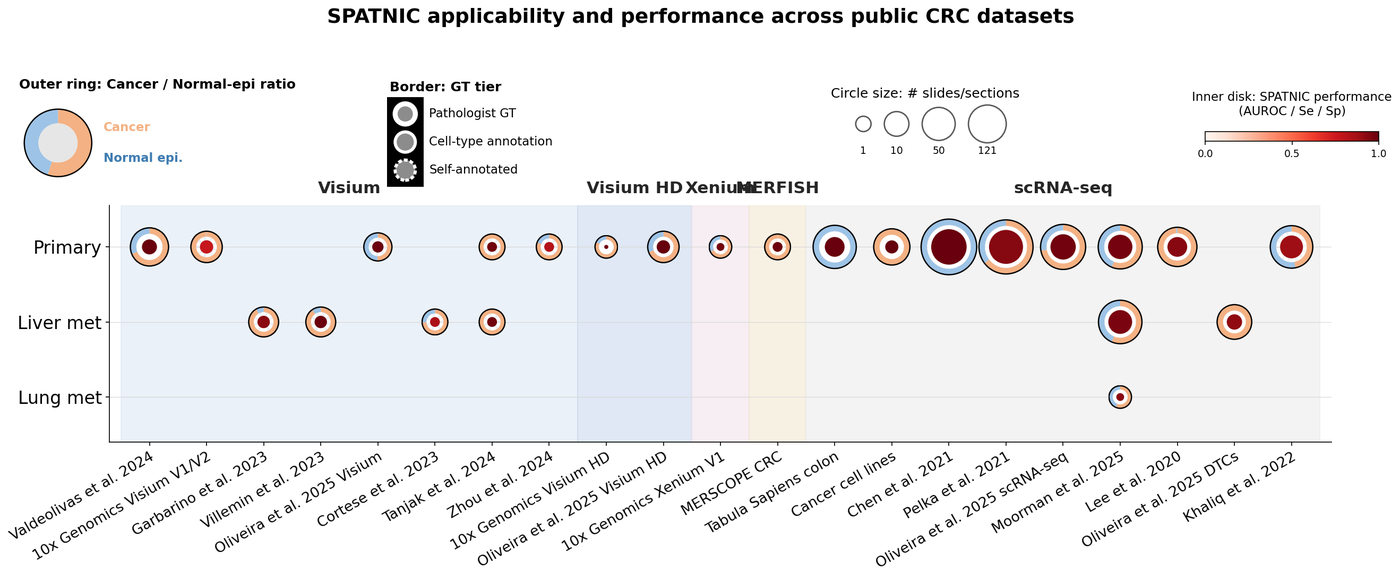

In [ ]:
# Fig 3a — applicability performance dot-plot
Image(str(COMP / "applicability/crc_applicability_performance_dotplot.png"))

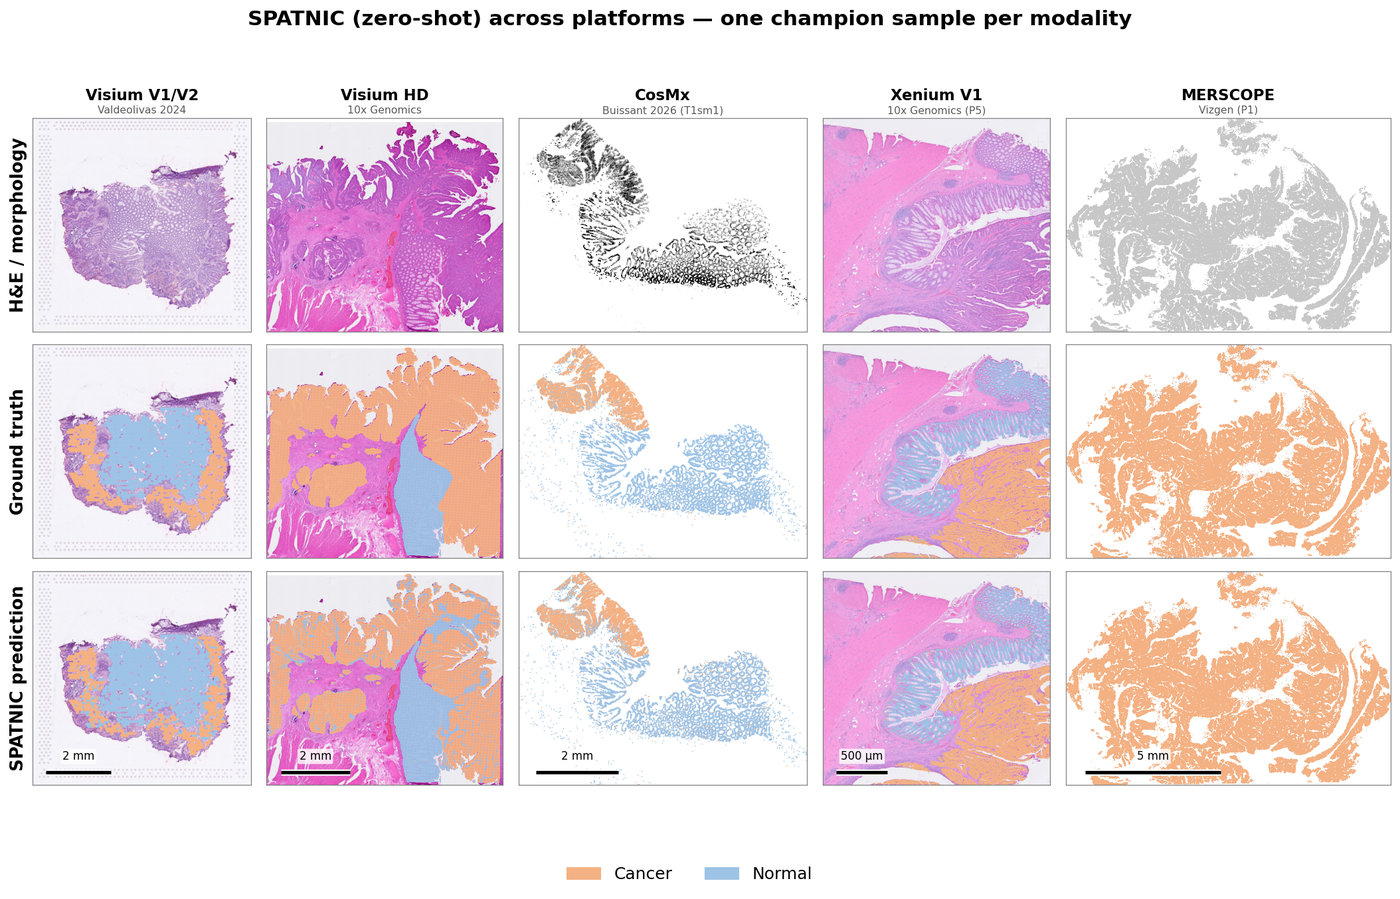

In [ ]:
# Fig 3b — per-modality spatial (True vs SPATNIC)
Image(str(COMP / "applicability/champion_spatial_per_modality.png"))

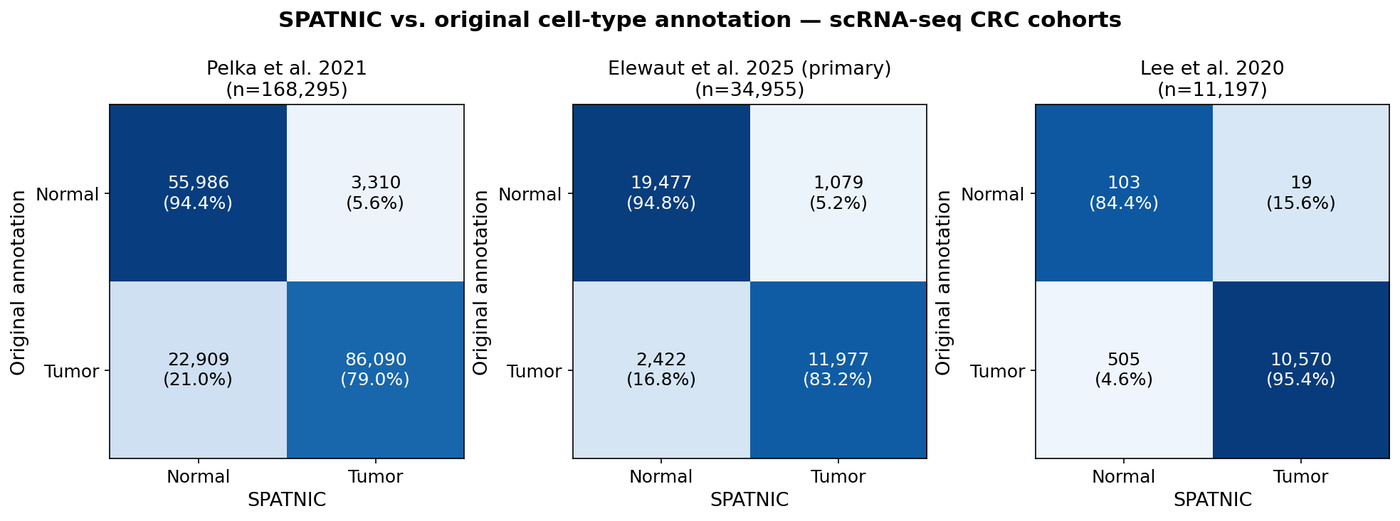

In [ ]:
# Fig 3c — scRNA-seq confusion (Pelka/Moorman/Lee)
Image(str(COMP / "scrnaseq_confusion/scrnaseq_confusion_matrices.png"))

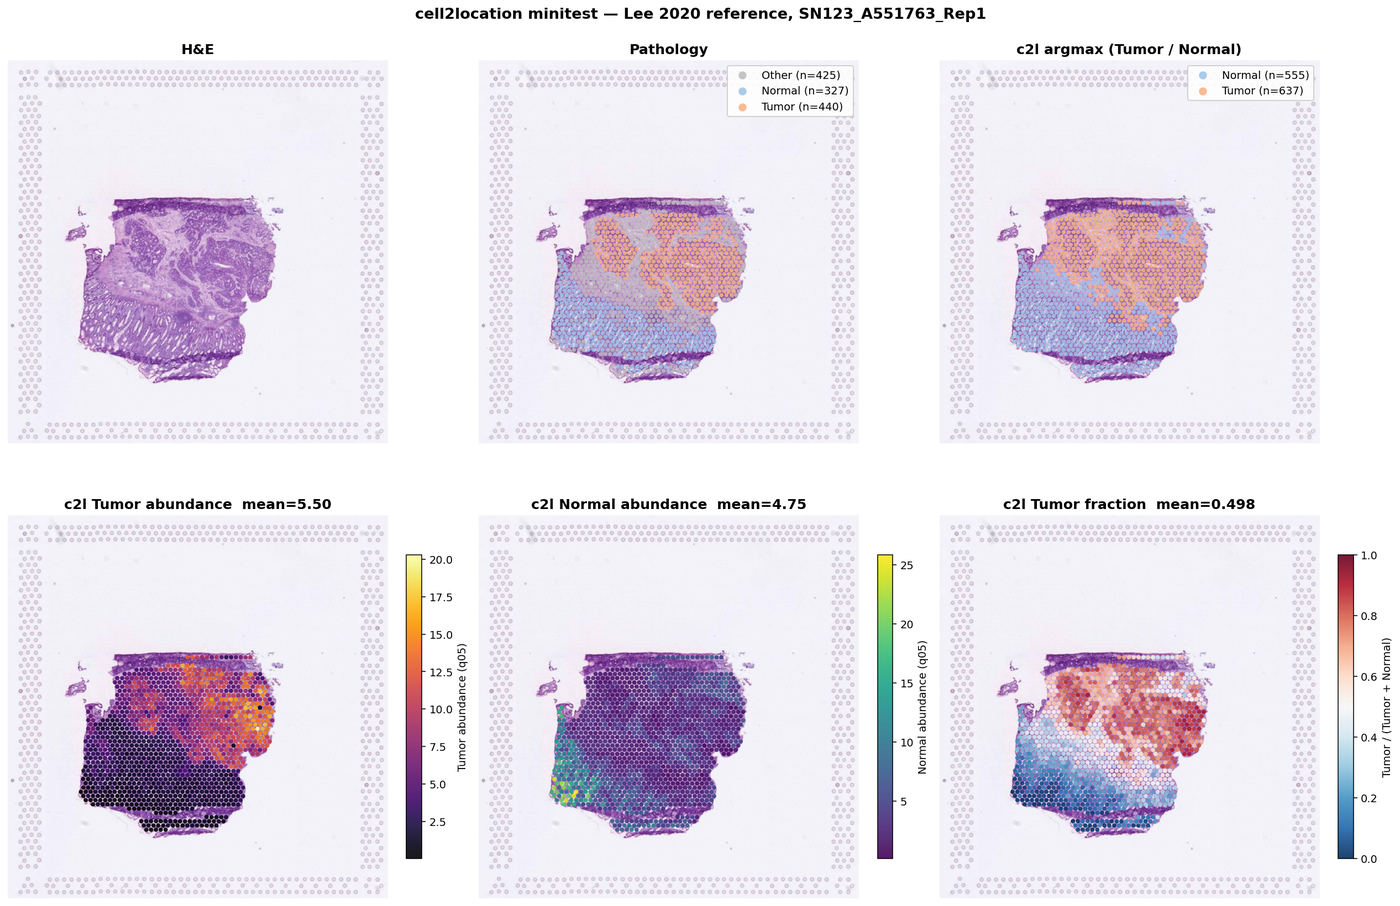

In [ ]:
# Fig 3d — cell2location deconvolution (ground truth)
Image(str(COMP / "c2l_minitest_lee/SN123_A595688_Rep1/spatial_overview.png"))